# 3.3 — Many instruments, few factors: multi-hedges and PCA

> *"The curve has twenty-four points and three degrees of freedom."*

## The problem

One hedge instrument leaves $(1-\rho^2)$ of the variance. If $\rho = 0.75$ (M12 against M1) that is 44 %
of the risk still on the book. A second instrument closer to the exposure — M6, say — could take much of
it. But two instruments raise two new problems:

1. **Sizing jointly**: the M6 hedge changes the optimal M1 hedge. The answer is multiple regression,
   equation (3.6): $\mathbf{w}^* = -\Sigma_{FF}^{-1}\Sigma_{FV}$. Simple to write; numerically
   treacherous when the instruments are nearly collinear (M1 and M2 are 94 % correlated).
2. **Choosing which**: with 24 tenors and say three liquid instruments, which three, and against what?

Both problems are resolved by the same observation: curve moves are driven by a small number of
**factors** — level, slope, curvature — that a **principal component analysis** (PCA) extracts from
$\Sigma$. Hedge the factors, not the tenors.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from gashedge.market_data import simulate_curve_history
from gashedge.hedging import multi_instrument_hedge, hedge_effectiveness, ols
from gashedge.risk import pca, portfolio_variance
from gashedge.plotting import plot_heatmap
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch3.3")
log.info("Environment ready")

2026-09-13 16:47:14.683 | INFO    | ch3.3 | Environment ready


## 1. Two instruments beat one — when they are different enough

In [2]:
hist = simulate_curve_history(n_days=750, n_tenors=24)
d = hist.diff().dropna()
target = d.M12

def hedged_var_fraction(target, hedges: list[str]) -> tuple[np.ndarray, float]:
    w = multi_instrument_hedge(target, d[hedges])
    resid = target - d[hedges].values @ w
    return w, resid.var() / target.var()

rows = []
for hedges in (["M1"], ["M6"], ["M1", "M6"], ["M1", "M2"], ["M1", "M3", "M6"], ["M6", "M9"], ["M11", "M13"]):
    w, frac = hedged_var_fraction(target, hedges)
    rows.append({"hedge set": "+".join(hedges), "weights (MWh per MWh)": np.round(w, 3).tolist(), "residual variance fraction": frac, "effectiveness": 1 - frac})
multi = pd.DataFrame(rows)
log.info("M12 hedged with M1 alone: %.0f%% effective; with M1+M6: %.0f%%; with M11+M13: %.0f%%", 100 * multi.effectiveness.iloc[0], 100 * multi.effectiveness.iloc[2], 100 * multi.effectiveness.iloc[-1])
multi.round(3)

2026-09-13 16:47:14.690 | INFO    | gashedge.market_data | Simulated constant-maturity curve history: 750 days x 24 tenors


2026-09-13 16:47:14.694 | INFO    | ch3.3 | M12 hedged with M1 alone: 55% effective; with M1+M6: 79%; with M11+M13: 91%


,hedge set,weights (MWh per MWh),residual variance fraction,effectiveness
0,M1,[0.361],0.449,0.551
1,M6,[0.786],0.218,0.782
2,M1+M6,"[-0.066, 0.892]",0.214,0.786
3,M1+M2,"[0.054, 0.473]",0.375,0.625
4,M1+M3+M6,"[-0.101, 0.104, 0.824]",0.211,0.789
5,M6+M9,"[0.168, 0.664]",0.136,0.864
6,M11+M13,"[0.451, 0.48]",0.093,0.907


Read the weights, not just the effectiveness:

* **M1 + M6**: the M6 weight is large, the M1 weight small (even negative) — M6 does the work, M1 mops up
  what is left. Adding a *closer* instrument matters far more than adding *another* instrument.
* **M1 + M2**: barely better than M1 alone, and the weights are large with opposite signs. Two
  instruments that are 94 % correlated carry almost the same information; the regression spreads the
  hedge between them arbitrarily. This is **multicollinearity**, and it is the numerical trap of (3.6).
* **M11 + M13**: near-perfect — but only because in the simulation those tenors are liquid. In reality
  they are not (Chapter 1.3); the hedge you *can* trade is the constraint.

## 2. Why collinearity is dangerous: the condition number

$\mathbf{w}^* = -\Sigma_{FF}^{-1}\Sigma_{FV}$ inverts $\Sigma_{FF}$. If two hedge instruments are nearly
identical, $\Sigma_{FF}$ is nearly singular: its smallest eigenvalue is tiny, its inverse is huge, and a
small estimation error in $\Sigma_{FV}$ becomes a large error in the weights. The **condition number**
$\kappa = \lambda_{\max}/\lambda_{\min}$ measures this amplification.

In [3]:
def condition_number(cols):
    # on the *correlation* matrix, so that it is scale-free: (1 + rho) / (1 - rho) for two instruments
    ev = np.linalg.eigvalsh(d[cols].corr().values)
    return ev.max() / ev.min()

def weight_instability(target, hedges, n_boot=300, seed=1):
    rng = np.random.default_rng(seed)
    ws = []
    n = len(target)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        ws.append(multi_instrument_hedge(target.values[idx], d[hedges].values[idx]))
    return np.std(ws, axis=0)

rows = []
for hedges in (["M1", "M2"], ["M1", "M3"], ["M1", "M6"], ["M1", "M12"]):
    rows.append({"hedge set": "+".join(hedges), "condition number": condition_number(hedges),
                 "bootstrap sd of weights": np.round(weight_instability(target, hedges), 3).tolist(),
                 "weights": np.round(multi_instrument_hedge(target, d[hedges]), 3).tolist()})
cond = pd.DataFrame(rows)
log.info("Condition number M1+M2 = %.0f vs M1+M12 = %.0f: nearly-collinear instruments give unstable weights", cond["condition number"].iloc[0], cond["condition number"].iloc[3])
cond

2026-09-13 16:47:14.855 | INFO    | ch3.3 | Condition number M1+M2 = 23 vs M1+M12 = 7: nearly-collinear instruments give unstable weights


,hedge set,condition number,bootstrap sd of weights,weights
0,M1+M2,23.309011,"[0.042, 0.063]","[0.054, 0.473]"
1,M1+M3,20.912076,"[0.043, 0.064]","[0.021, 0.518]"
2,M1+M6,15.045652,"[0.028, 0.051]","[-0.066, 0.892]"
3,M1+M12,6.756649,"[0.0, 0.0]","[0.0, 1.0]"


## 3. Principal components: the curve's own coordinates

Diagonalise the covariance matrix: $\Sigma = V\Lambda V^\top$, with eigenvectors $V$ (the *loadings*) and
eigenvalues $\Lambda$ (the variance carried by each component). Curve moves can then be written as

$$
\Delta\mathbf{P}_t = \sum_{k=1}^{n} v_k\, z_{k,t}, \qquad z_{k,t} = v_k^\top\Delta\mathbf{P}_t,\qquad \text{Var}(z_k) = \lambda_k
\tag{3.14}
$$

where the $z_k$ are uncorrelated *factor scores*. For curves, three components typically explain
90 %+ of variance, and their loadings have recognisable shapes — **level** (all tenors move together),
**slope** (front vs back), **curvature** (middle vs ends). Details in
[Appendix C](../appendix/C_notation_pca_references.ipynb).

2026-09-13 16:47:14.860 | INFO    | gashedge.risk | PCA explained variance: [0.819 0.115 0.013]


2026-09-13 16:47:14.919 | INFO    | ch3.3 | PC1..3 explain 81.9%, 11.5%, 1.3% of variance (cumulative 94.7%)


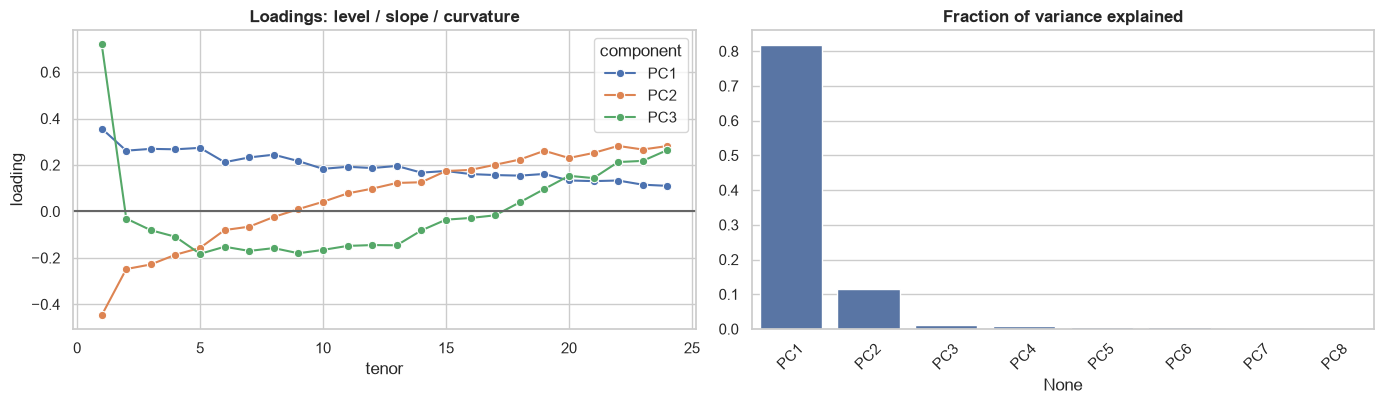

In [4]:
res = pca(d, n_components=3)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
load = res["loadings"].rename_axis("tenor").reset_index().melt(id_vars="tenor", var_name="component", value_name="loading")
load["tenor_i"] = load.tenor.str[1:].astype(int)
sns.lineplot(data=load, x="tenor_i", y="loading", hue="component", marker="o", ax=axes[0]); axes[0].axhline(0, color="0.4")
axes[0].set_title("Loadings: level / slope / curvature"); axes[0].set_xlabel("tenor")
expl = pd.Series(res["eigval"] / res["eigval"].sum(), index=[f"PC{i + 1}" for i in range(24)])
sns.barplot(x=expl.index[:8], y=expl.values[:8], ax=axes[1]); axes[1].set_title("Fraction of variance explained"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
log.info("PC1..3 explain %.1f%%, %.1f%%, %.1f%% of variance (cumulative %.1f%%)", *(100 * res["explained"]), 100 * res["explained"].sum())

## 4. Factor hedging: neutralise the components you can

A book with delta vector $\mathbf{q}$ has exposure $\beta_k = \mathbf{q}^\top v_k$ to component $k$, and
(because components are uncorrelated) its variance decomposes cleanly:

$$
\text{Var}(\Delta V) = \sum_k \beta_k^2\,\lambda_k
\tag{3.15}
$$

With $m$ hedge instruments you can neutralise $m$ factor exposures exactly: choose $\mathbf{w}$ (MWh in
each instrument) so that $(\mathbf{q} + H\mathbf{w})^\top v_k = 0$ for $k = 1..m$, where $H$ maps
instruments to tenors. Neutralise PC1 with one liquid contract and you have removed the level risk that
dominates; add a second instrument *from the other end of the curve* for slope (the loadings must have
opposite slope signs, or the system is ill-conditioned). This is how curve desks think — in *factors*, not
tenors.

In [5]:
tenors = list(d.columns)
V = res["loadings"].values                       # 24 x 3
lam = res["eigval"][:3]

# Book from Chapter 3.1
book = pd.Series(0.0, index=tenors)
book[["M1", "M2"]] = [18_000, -6_000]; book[["M4", "M5", "M6"]] = -12_000
book[["M13", "M14", "M15", "M16", "M17", "M18"]] = 7_000

def factor_exposures(q):
    return pd.Series(V.T @ q.values, index=["PC1 (level)", "PC2 (slope)", "PC3 (curvature)"])

def factor_hedge(q, instruments, n_factors):
    # solve for w so that the first n_factors exposures are zero (n_factors == len(instruments))
    H = np.zeros((len(tenors), len(instruments)))
    for j, ins in enumerate(instruments):
        H[tenors.index(ins), j] = 1.0
    A = V[:, :n_factors].T @ H                   # n_factors x n_instruments
    w = np.linalg.solve(A, -(V[:, :n_factors].T @ q.values))
    return pd.Series(w, index=instruments), q + H @ w

Sigma = d.cov()
results = {"unhedged": book}
w1, hedged1 = factor_hedge(book, ["M1"], 1)
w2, hedged2 = factor_hedge(book, ["M1", "M18"], 2)
w3, hedged3 = factor_hedge(book, ["M1", "M6", "M18"], 3)
results.update({"PC1 hedged (M1)": hedged1, "PC1+PC2 hedged (M1,M18)": hedged2, "PC1-3 hedged (M1,M6,M18)": hedged3})
summary = pd.DataFrame({k: {**factor_exposures(q).to_dict(), "daily std (EUR)": np.sqrt(portfolio_variance(q, Sigma))} for k, q in results.items()}).T
log.info("Factor hedges: %s", {k: round(v["daily std (EUR)"]) for k, v in summary.iterrows()})
log.info("Hedge weights (MWh): PC1 -> %s ; PC1+2 -> %s ; PC1-3 -> %s", w1.round(0).to_dict(), w2.round(0).to_dict(), w3.round(0).to_dict())
summary.round(0)

2026-09-13 16:47:15.023 | INFO    | ch3.3 | Factor hedges: {'unhedged': 14883, 'PC1 hedged (M1)': 13439, 'PC1+PC2 hedged (M1,M18)': 9939, 'PC1-3 hedged (M1,M6,M18)': 8538}


2026-09-13 16:47:15.024 | INFO    | ch3.3 | Hedge weights (MWh): PC1 -> {'M1': -8056.0} ; PC1+2 -> {'M1': 1580.0, 'M18': -22331.0} ; PC1-3 -> {'M1': -13179.0, 'M6': 36771.0, 'M18': -38715.0}


,PC1 (level),PC2 (slope),PC3 (curvature),daily std (EUR)
unhedged,2875.0,5691.0,16603.0,14883.0
PC1 hedged (M1),-0.0,9299.0,10797.0,13439.0
"PC1+PC2 hedged (M1,M18)",-0.0,0.0,16871.0,9939.0
"PC1-3 hedged (M1,M6,M18)",0.0,-0.0,0.0,8538.0


Compare with the *minimum-variance* hedge in the same instruments (equation 3.6): factor hedging is
less efficient in-sample — it neutralises the factors exactly and ignores the idiosyncratic noise and
the components beyond $m$ — but it is **more stable and more explainable**, because it inverts a small,
well-conditioned $m\times m$ matrix of loadings rather than $\Sigma_{FF}$ directly, and because the
loadings change slowly over time while individual covariances jump around. (Try `["M1", "M6"]` as the
two-instrument set: the slope loadings of M1 and M6 have the same sign, $A$ is nearly singular, and the
"hedge" adds risk — the collinearity trap in factor clothing.)

In [6]:
def minvar_in(q, instruments):
    S_FF = Sigma.loc[instruments, instruments].values
    pnl = d[tenors].values @ q.values
    S_FV = np.array([np.cov(d[i], pnl, ddof=1)[0, 1] for i in instruments])
    w = -np.linalg.solve(S_FF, S_FV)
    hq = q.copy()
    for i, wi in zip(instruments, w):
        hq[i] += wi
    return pd.Series(w, index=instruments), np.sqrt(portfolio_variance(hq, Sigma))

cmp_rows = []
for ins, (wf, hf) in zip((["M1"], ["M1", "M18"], ["M1", "M6", "M18"]), ((w1, hedged1), (w2, hedged2), (w3, hedged3))):
    wm, std_m = minvar_in(book, ins)
    cmp_rows.append({"instruments": "+".join(ins), "factor-hedge std": np.sqrt(portfolio_variance(hf, Sigma)), "min-variance std": std_m,
                     "factor weights": wf.round(0).tolist(), "min-var weights": wm.round(0).tolist()})
pd.DataFrame(cmp_rows).round(0)

,instruments,factor-hedge std,min-variance std,factor weights,min-var weights
0,M1,13439.0,13027.0,[-8056.0],[-5523.0]
1,M1+M18,9939.0,9572.0,"[1580.0, -22331.0]","[-883.0, -18538.0]"
2,M1+M6+M18,8538.0,7461.0,"[-13179.0, 36771.0, -38715.0]","[-9068.0, 22476.0, -28812.0]"


## 5. Choosing instruments: a rule

Given PCA, the choice of hedge instruments becomes a design question with a clear answer: pick the
**most liquid instrument with a large loading on each factor you want to neutralise**. For level, the
front month (or the front season). For slope, something far enough along the curve that its slope
loading has the opposite sign — M6–M12, or the second season. For curvature (rarely worth hedging), a
mid-curve contract. Then check the condition number of the resulting loading matrix $A$ — if it is
large, your instruments are too similar.

## 6. Where this leaves us

Multiple regression sizes several hedges jointly; collinearity makes it fragile; PCA reveals that three
factors carry most curve risk and gives a stable way to hedge them with a few liquid instruments.

**Pitfall that leads to the next chapter:** we have reported everything as a standard deviation. Desk
heads and regulators want a **loss number at a confidence level** — Value at Risk — and they want to
know it holds up when the world is not Gaussian and when it takes days to exit. That is Chapter 3.4.

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** Two hedge instruments have daily variances 1.44 and 1.21 and correlation 0.95. Compute $\Sigma_{FF}$, its eigenvalues (to two decimals) and condition number. Then explain in one sentence why a 1 % error in $\Sigma_{FV}$ can produce a much larger percentage error in the weights.

<details><summary><i>Answer 1</i></summary>

$\Sigma_{FF} = \begin{pmatrix}1.44 & 1.254\\1.254 & 1.21\end{pmatrix}$ (cov $= 0.95\times1.2\times1.1 = 1.254$). Eigenvalues solve $\lambda^2 - 2.65\lambda + (1.7424 - 1.5725) = 0 \Rightarrow \lambda^2 - 2.65\lambda + 0.1699 = 0$; $\lambda = (2.65 \pm \sqrt{7.0225 - 0.6796})/2 = (2.65 \pm 2.518)/2 \Rightarrow \lambda_{\max} \approx \mathbf{2.58}, \lambda_{\min} \approx \mathbf{0.066}$; condition number $\approx \mathbf{39}$. The inverse scales errors along the small-eigenvalue direction by $1/\lambda_{\min} \approx 15$ (relative to $1/\lambda_{\max} \approx 0.4$, a factor ~39): a small perturbation of $\Sigma_{FV}$ in the direction 'long one, short the other' is amplified ~39× into the weights, producing large offsetting positions that cancel in risk terms but not in transaction costs.

</details>

**Q2.** A book has factor exposures $\beta_1 = 40{,}000$ (level), $\beta_2 = -15{,}000$ (slope), $\beta_3 = 5{,}000$ (curvature) in MWh-weighted loading units, and the factor variances are $\lambda = (2.0, 0.25, 0.03)$. Compute the daily P&L variance and standard deviation via (3.15), and the fraction removed by hedging PC1 alone.

<details><summary><i>Answer 2</i></summary>

$\text{Var} = 40{,}000^2\times2.0 + 15{,}000^2\times0.25 + 5{,}000^2\times0.03 = 3.2\times10^9 + 5.625\times10^7 + 7.5\times10^5 = 3.2570\times10^9$; std $\approx \mathbf{€57{,}070}$. Hedging PC1 removes $3.2\times10^9/3.257\times10^9 = \mathbf{98.2\%}$ of the variance; the residual std is $\sqrt{5.7\times10^7} \approx €7{,}550$. (Note the subtlety: 'MWh-weighted loading units' assumes unit-norm eigenvectors, as `numpy.linalg.eigh` returns.)

</details>

**Q3.** Factor hedging PC1 with the front month and minimum-variance hedging with the front month gave *different* weights. Which is smaller in absolute value, and why? When would you prefer each?

<details><summary><i>Answer 3</i></summary>

They differ because min-variance uses $\text{Cov}(\Delta F_1, \Delta V)/\text{Var}(\Delta F_1)$ — all covariances, including the exposure's idiosyncratic and higher-factor co-movement with M1 — while the PC1 hedge uses only the level factor. Which is smaller depends on the book: a book whose non-level exposures happen to be *positively* correlated with M1 gets a larger min-var hedge. Prefer **min-variance** when the covariance estimate is trustworthy and the goal is pure variance minimisation over the estimation window; prefer **factor hedging** when the covariance is noisy or regime-prone (its inputs — loadings — are more stable), when you want a hedge that is *explainable* ('we are level-flat'), or when limits are expressed in factor terms.

</details>

**Q4.** Your only liquid instruments are M1 and the Win-27 season (six tenors, M13–M18, equal MW). Set up the factor-hedge system for PC1 and PC2: what is the matrix $A$ in terms of the loadings, and what condition on the loadings makes the system solvable?

<details><summary><i>Answer 4</i></summary>

Instruments map to tenors via $H$: column 1 is the unit vector on M1; column 2 puts $1/6$ (or 1 MW × hours, if you keep MWh) on each of M13–M18. Then $A = V_{[:,1:2]}^\top H$ is $2\times2$ with entries $A_{k1} = v_k(\text{M1})$ and $A_{k2} = \tfrac16\sum_{i=13}^{18} v_k(\text{M}i)$ for $k=1,2$. Solvable iff $\det A \neq 0$, i.e. the two instruments have *different ratios* of slope-to-level loading: $v_2(\text{M1})/v_1(\text{M1}) \neq \bar v_2(\text{Win})/\bar v_1(\text{Win})$. Since the slope loading changes sign between the front and the back, this holds comfortably — front month and far season are close to ideal partners for a level/slope hedge.

</details>


---
◀ [Previous](02_minimum_variance_hedge.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](04_residual_risk_var.ipynb)